# CropCatcher — Réconciliation de folios / Folio reconciliation

**FR** — Ce notebook prend un CSV où une ligne = un folio (image locale) associé au manifeste IIIF de son manuscrit, et produit un CSV donnant pour chaque folio les N meilleurs canvas candidats. La recherche étant la partie coûteuse, on la lance une fois avec un `TOP_K` généreux : réduire ensuite à un ou deux candidats est un simple filtre sur la sortie.

**EN** — This notebook takes a CSV where one row = one folio (a local image) paired with its manuscript's IIIF manifest, and produces a CSV giving the top-N candidate canvases per folio. The search is the expensive part, so run it once with a generous `TOP_K`: narrowing to one or two candidates is then a free filter on the output.

## 1. Paramètres / Parameters

**FR/EN** — Tout se règle ici. / Everything is configured here.

In [1]:
from pathlib import Path

# Inputs
FOLIOS_CSV = Path("../data/folios.csv")
IMAGES_DIR = Path("/home/lterriel/Documents/ENC-PSL/Projets/ODIL/Data/medieval_images")

# Output
OUTPUT_CSV = Path("../data/folios_reconciled.csv")

# How many candidates to keep per folio
TOP_K = 3

# Matching settings
METHOD = "sift"          # "sift", "akaze", "orb"
SIZE = "!1024,1024"      # IIIF size requested for each canvas
MAX_WORKERS = 16         # CPU-bound: close to the core count

# Mutual check: keep a match only if the candidate descriptor also has the query
# as its own nearest neighbour. Measured on the Mandragore set: precision
# 0.26 -> 0.91 and score margin 0.28 -> 0.62, for +22% time.
MUTUAL_CHECK = True
# Caps the canvases indexed per manifest. None = the whole manuscript.
# WARNING: manifests usually hold FAR more canvases than the CSV has folios (often
# hundreds). Truncating therefore almost certainly excludes the right page: use this
# for throughput tests only, never for a real reconciliation.
MAX_CANVASES = None

# Search window around the expected page. This is THE cost lever: instead of
# indexing the whole manuscript, index only the few canvases whose labels surround
# the folio we are looking for. None = the whole manifest.
SEARCH_WINDOW = 20

# What to do when the folio label cannot be found in the manifest:
#   "skip" -> leave that folio out (fast, but misses unusual labels)
#   "full" -> fall back to the whole manuscript (safe, but costly)
ON_MISSING_LABEL = "skip"

# Resume: skip manifests already present in OUTPUT_CSV and append results as they
# come. Essential for a batch of several hours, which will be interrupted sooner or
# later. Set to False to start over.
# NB: if you change METHOD / SIZE / SEARCH_WINDOW, delete OUTPUT_CSV, otherwise the
# old results are kept as they are.
RESUME = True

# Safety rails. None = no limit (a batch job of several hours!)
LIMIT_MANIFESTS = 2           # manifests processed
MAX_FOLIOS_PER_MANIFEST = 3   # folios processed per manifest

# For the demo, target a manifest whose expected page is known to exist (Vatican
# Reg.lat.610: folio 1R in the CSV matches canvas "1r").
# Set to [] to process the corpus in CSV order.
FOCUS_MANIFESTS = ["https://digi.vatlib.it/iiif/MSS_Reg.lat.610/manifest.json"]


## 2. Charger et filtrer le CSV / Load and filter the CSV

**FR** — Une ligne est exploitable si son image existe sur le disque et si elle porte au moins une URL de manifeste (`blank` signale l'absence). Une ligne peut en porter plusieurs, séparées par `|`.

**EN** — A row is usable if its image exists on disk and it carries at least one manifest URL (`blank` marks the absence). A row may carry several, separated by `|`.

In [2]:
import pandas as pd

folios = pd.read_csv(FOLIOS_CSV)
print(f"rows in the CSV : {len(folios)}")
print(f"columns         : {list(folios.columns)}")

BLANK = {"blank", "", "nan", "none"}

folios["image_path"] = folios["odil_folio_filename"].apply(lambda name: IMAGES_DIR / str(name))
folios["has_image"] = folios["image_path"].apply(lambda p: p.is_file())
folios["has_manifest"] = (
    folios["manuscript_iiif_manifest_urls"].fillna("").str.strip().str.lower().apply(
        lambda v: v not in BLANK
    )
)

usable = folios[folios["has_image"] & folios["has_manifest"]].copy()
print(f"\nwith an image on disk : {folios['has_image'].sum()}")
print(f"with a IIIF manifest  : {folios['has_manifest'].sum()}")
print(f"usable (both)         : {len(usable)}")


rows in the CSV : 32580
columns         : ['odil_folio_filename', 'alhoma_manuscript_id', 'title', 'folio', 'alhoma_folio_id', 'odil_folio_id', 'conservation_institution', 'manuscript_call-number', 'manuscript_iiif_manifest_urls']



with an image on disk : 31842
with a IIIF manifest  : 20704
usable (both)         : 20351


## 3. Grouper par manifeste / Group by manifest

**FR** — Point de performance clé : plusieurs folios partagent le même manuscrit, environ huit en moyenne. Appeler `search_iiif` folio par folio retéléchargerait tout le manifeste à chaque fois. On construit donc un `Index` une fois par manifeste, puis on y cherche chacun de ses folios sans accès réseau supplémentaire.

**EN** — The key performance point: several folios share the same manuscript, about eight on average. Calling `search_iiif` folio by folio would re-download the whole manifest every time. So we build an `Index` once per manifest, then search each of its folios in it with no further network access.

In [3]:
groups = usable.groupby("manuscript_iiif_manifest_urls", sort=False)
print(f"distinct manifests : {groups.ngroups}")

sizes = groups.size().sort_values(ascending=False)
print(f"folios per manifest : median={int(sizes.median())}, "
      f"mean={sizes.mean():.1f}, max={int(sizes.max())}")
print("\nlargest manifests:")
print(sizes.head(5).to_string())


distinct manifests : 2659
folios per manifest : median=2, mean=7.7, max=1388

largest manifests:
manuscript_iiif_manifest_urls
https://digi.vatlib.it/iiif/MSS_Reg.lat.1/manifest.json                                   1388
https://api.irht.cnrs.fr/ark:/63955/fp97pcnufrsj/manifest.json                             800
https://api.irht.cnrs.fr/ark:/63955/fsrtgzdiq1xn/manifest.json                             399
https://iiif.bodleian.ox.ac.uk/iiif/manifest/31dcbc95-b922-4d66-8c83-e01e9300afe5.json     383
https://digi.vatlib.it/iiif/MSS_Urb.lat.115/manifest.json                                  371


## 4. Réconcilier / Reconcile

**FR** — Pour chaque manifeste : résoudre ses canvas afin d'en récupérer les étiquettes, construire l'`Index`, puis chercher chaque folio. Une erreur sur un manifeste est enregistrée sans interrompre le batch, et les erreurs réseau transitoires sont déjà retentées avec backoff par la couche IIIF.

**FR** — `RESUME` rend le batch redémarrable : chaque manifeste terminé est écrit aussitôt, et ceux déjà présents sont sautés. `SEARCH_WINDOW` est le levier de coût décisif : le folio attendu est connu et le manifeste expose des étiquettes, donc on n'indexe que les canvas autour de la position probable. Comme indexer suppose de télécharger, cela réduit réseau et comparaisons à la fois. On indexe l'union des fenêtres du manuscrit, ce qui laisse voir un éventuel décalage de foliotation. Un folio dont l'étiquette est introuvable sort en `skipped_no_label`.

**EN** — For each manifest: resolve its canvases to recover their labels, build the `Index`, then search each folio. An error on one manifest is recorded without stopping the batch, and transient network failures are already retried with backoff by the IIIF layer.

**EN** — `RESUME` makes the batch restartable: each finished manifest is written at once, and those already present are skipped. `SEARCH_WINDOW` is the decisive cost lever: the expected folio is known and the manifest exposes labels, so only the canvases around the likely position are indexed. Since indexing means downloading, this cuts network and comparisons at once. We index the union of the manuscript's windows, which leaves a foliation offset visible. A folio whose label cannot be located comes out as `skipped_no_label`.

In [4]:
import re
import time

from cropcatcher import Index
from cropcatcher.sources.iiif import resolve_manifest


def normalize_folio(value) -> str:
    """Reduce a folio or canvas label to a comparable form: 175, r/v -> "175r"."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    match = re.search(r"(\d+)\s*([rv])", str(value).lower())
    return f"{int(match.group(1))}{match.group(2)}" if match else ""


def reconcile_manifest(manifest_urls: str, rows: pd.DataFrame) -> tuple[list[dict], dict]:
    """Reconcile every folio of one manuscript against its manifest(s).

    Returns the result records plus a timing breakdown separating index
    construction (paid once per manifest) from searching (paid per folio),
    since only the second scales with the number of folios.
    """
    urls = [u for u in str(manifest_urls).split("|") if u.strip()]

    # Resolve once: we need the labels (absent from the Index) AND the canvas
    # order, since the window is defined by position in the manuscript.
    resources = []
    for url in urls:
        resources.extend(resolve_manifest(url, max_canvases=MAX_CANVASES))
    labels = {r.service_id: r.canvas_label for r in resources}

    # normalized folio label -> position in the manifest
    positions = {}
    for position, resource in enumerate(resources):
        key = normalize_folio(resource.canvas_label)
        if key and key not in positions:
            positions[key] = position

    # Select the canvases worth indexing: the union of the windows around each
    # folio we are looking for, instead of the whole manuscript.
    unlocated = set()
    if SEARCH_WINDOW:
        half = max(1, SEARCH_WINDOW // 2)
        wanted: set[int] = set()
        for _, row in rows.iterrows():
            position = positions.get(normalize_folio(row["folio"]))
            if position is None:
                unlocated.add(row["odil_folio_id"])
                continue
            wanted.update(
                range(max(0, position - half), min(len(resources), position + half + 1))
            )
        if unlocated and ON_MISSING_LABEL == "full":
            wanted = set(range(len(resources)))
            unlocated.clear()
        selected = [resources[i] for i in sorted(wanted)]
    else:
        selected = resources

    index = Index(method=METHOD, mutual_check=MUTUAL_CHECK)
    build_started = time.perf_counter()
    index.add_iiif_services(
        [r.service_id for r in selected], size=SIZE, max_workers=MAX_WORKERS
    )
    build_seconds = time.perf_counter() - build_started

    # Is the folio we are looking for even present among the indexed canvases?
    # A manifest often digitizes only part of a manuscript, so "not found" and
    # "not there to begin with" must not be confused.
    indexed_folios = {normalize_folio(r.canvas_label) for r in selected}
    indexed_folios.discard("")

    output = []
    search_seconds = 0.0
    for _, row in rows.iterrows():
        expected = normalize_folio(row["folio"])
        if row["odil_folio_id"] in unlocated:
            output.append({
                "odil_folio_id": row["odil_folio_id"],
                "alhoma_manuscript_id": row["alhoma_manuscript_id"],
                "title": row["title"], "folio": row["folio"],
                "manifest_urls": manifest_urls, "n_canvases_indexed": len(index),
                "target_in_manifest": False, "rank": None,
                "candidate_service_id": None, "candidate_canvas_label": None,
                "score": None, "matches": None, "inliers": None,
                "inlier_ratio": None, "bbox": None,
                "status": "skipped_no_label",
                "error": "folio not found among the manifest labels",
            })
            continue

        search_started = time.perf_counter()
        results = index.search(row["image_path"], max_workers=MAX_WORKERS)
        search_seconds += time.perf_counter() - search_started
        for rank, result in enumerate(results.top(TOP_K), start=1):
            output.append({
                "odil_folio_id": row["odil_folio_id"],
                "alhoma_manuscript_id": row["alhoma_manuscript_id"],
                "title": row["title"],
                "folio": row["folio"],
                "manifest_urls": manifest_urls,
                "n_canvases_indexed": len(index),
                "target_in_manifest": expected in indexed_folios if expected else None,
                "rank": rank,
                "candidate_service_id": result.source,
                "candidate_canvas_label": labels.get(result.source),
                "score": round(result.score, 4),
                "matches": result.matches,
                "inliers": result.inliers,
                "inlier_ratio": round(result.inlier_ratio, 4),
                "bbox": result.bbox,
                "status": "ok",
                "error": None,
            })

    breakdown = {
        # only searched folios cost anything, so calibrate the estimate on those
        "n_folios": len(rows) - len(unlocated),
        "n_skipped": len(unlocated),
        "n_canvases": len(index),
        "n_canvases_available": len(resources),
        "build_seconds": build_seconds,
        "search_seconds": search_seconds,
    }
    return output, breakdown


records = []
timings = []  # real measurements, used below to estimate the total cost

done_manifests = set()
if RESUME and OUTPUT_CSV.exists():
    already = pd.read_csv(OUTPUT_CSV)
    done_manifests = set(already["manifest_urls"].dropna())
    print(f"resuming: {len(done_manifests)} manifests already done, "
          f"{len(already)} rows kept")
elif OUTPUT_CSV.exists():
    OUTPUT_CSV.unlink()
    print("RESUME=False: previous output deleted")


def append_to_csv(rows: list[dict]) -> None:
    """Write results as they come, so an interrupted run loses nothing."""
    if not rows:
        return
    header = not OUTPUT_CSV.exists()
    pd.DataFrame.from_records(rows).to_csv(
        OUTPUT_CSV, mode="a", header=header, index=False
    )


if FOCUS_MANIFESTS:
    wanted = set(FOCUS_MANIFESTS)
    todo = [(url, rows) for url, rows in groups if url in wanted]
else:
    todo = list(groups)[:LIMIT_MANIFESTS] if LIMIT_MANIFESTS else list(groups)

for position, (manifest_urls, rows) in enumerate(todo, start=1):
    if manifest_urls in done_manifests:
        print(f"[{position}/{len(todo)}] already done, skipped")
        continue
    if MAX_FOLIOS_PER_MANIFEST:
        rows = rows.head(MAX_FOLIOS_PER_MANIFEST)
    started = time.perf_counter()
    try:
        found, breakdown = reconcile_manifest(manifest_urls, rows)
        records.extend(found)
        append_to_csv(found)
        timings.append({"manifest_urls": manifest_urls, **breakdown})
        status = (f"{breakdown['n_folios']} folios x {breakdown['n_canvases']}"
                  f"/{breakdown['n_canvases_available']} canvases indexed "
                  f"-> {len(found)} rows  "
                  f"(index {breakdown['build_seconds']:.0f}s + search "
                  f"{breakdown['search_seconds']:.0f}s"
                  + (f", {breakdown['n_skipped']} without a label" if breakdown["n_skipped"] else "")
                  + ")")
    except Exception as error:  # noqa: BLE001 - one bad manifest must not stop the batch
        failed = [{
            "odil_folio_id": row["odil_folio_id"],
            "alhoma_manuscript_id": row["alhoma_manuscript_id"],
            "title": row["title"],
            "folio": row["folio"],
            "manifest_urls": manifest_urls,
            "rank": None, "candidate_service_id": None, "candidate_canvas_label": None,
            "score": None, "matches": None, "inliers": None, "inlier_ratio": None,
            "bbox": None, "n_canvases_indexed": None, "target_in_manifest": None,
            "status": "error", "error": f"{type(error).__name__}: {error}",
        } for _, row in rows.iterrows()]
        records.extend(failed)
        append_to_csv(failed)
        status = f"FAILED - {type(error).__name__}"

    elapsed = time.perf_counter() - started
    print(f"[{position}/{len(todo)}] {elapsed:6.1f}s  {status}  {str(manifest_urls)[:70]}")


[1/1]    4.4s  1 folios x 15/142 canvases indexed -> 3 rows  (index 2s + search 2s)  https://digi.vatlib.it/iiif/MSS_Reg.lat.610/manifest.json


## 5. Estimer le coût total / Estimating the total cost

FR — On estime le coût à partir d'un petit test réel. On mesure combien de temps prend l'indexation d'un canvas et combien de temps prend la comparaison d'un folio avec un canvas, puis on extrapole au corpus complet.

Pour un manuscrit avec N canvases et F folios :

$$
coût ≈ N × t_{index}
     + F × N × t_{compare}
$$

L'indexation des N canvases n'est faite qu'une fois. En revanche, chaque folio doit être comparé aux N canvases, donc le coût de matching augmente avec le nombre de folios.

Comme les manifestes n'ont pas tous la même taille, on estime leur taille moyenne sur un échantillon plutôt que de télécharger les 2 659 manifestes.

EN — We estimate the total cost from a small real run. We measure how long it takes to index one canvas and to compare one folio against one canvas, then extrapolate to the full corpus.

For a manuscript with N canvases and F folios:

$$
cost ≈ N × t_{index}
     + F × N × t_{compare}
$$

The N canvases are indexed only once. Each folio, however, must be compared against all N canvases, so matching cost grows with the number of folios.

Because manifest sizes vary, we estimate their average size from a sample instead of downloading all 2,659 manifests.

In [5]:
import random

SAMPLE_SIZE = 8  # manifests sampled to estimate their mean size

# When resuming, every manifest may have been skipped: there is then nothing new
# to time, and so nothing to extrapolate from.
if not timings:
    print("no manifest processed in this run (everything was already done):"
          " no new measurement, estimate not recomputed.")
else:
    runs = pd.DataFrame(timings)
    runs["comparisons"] = runs["n_folios"] * runs["n_canvases"]
    print(runs[["n_folios", "n_canvases", "comparisons",
                "build_seconds", "search_seconds"]].to_string(index=False))
    
    # Two distinct costs: indexing a canvas is paid ONCE per manifest, comparing a
    # (folio x canvas) pair is paid for every folio.
    sec_per_canvas_indexed = runs["build_seconds"].sum() / runs["n_canvases"].sum()
    sec_per_comparison = runs["search_seconds"].sum() / runs["comparisons"].sum()
    print(f"\nindex one canvas       : {sec_per_canvas_indexed * 1000:.0f} ms (once per manifest)")
    print(f"compare folio x canvas : {sec_per_comparison * 1000:.0f} ms (for every folio)")
    
    # Each index.search() call first describes the query (~1 s), a fixed cost spread
    # over the N comparisons. Calibrating on a small index therefore inflates the unit
    # cost and makes the projection pessimistic.
    if runs["n_canvases"].mean() < 100:
        print(f"\n  /!\\ calibrated on small indexes ({runs['n_canvases'].mean():.0f} canvases on\n"
              "      average): describing the query weighs heavily there, so the cost per\n"
              "      comparison is overestimated and the projection below is pessimistic.")
    
    # Mean manifest size, estimated on a sample.
    random.seed(0)
    sample_urls = random.sample([u for u, _ in groups if "|" not in u], SAMPLE_SIZE)
    sizes_sample = []
    for url in sample_urls:
        try:
            sizes_sample.append(len(resolve_manifest(url)))
        except Exception:
            pass
    
    mean_canvases = sum(sizes_sample) / len(sizes_sample)
    total_folios = len(usable)
    total_manifests = groups.ngroups
    mean_folios = total_folios / total_manifests
    
    # Canvases actually indexed per manifest: the whole manuscript, or only the union
    # of the windows (at most folios x window).
    if SEARCH_WINDOW:
        canvases_per_manifest = min(mean_canvases, mean_folios * SEARCH_WINDOW)
        canvases_per_search = min(mean_canvases, mean_folios * SEARCH_WINDOW)
    else:
        canvases_per_manifest = mean_canvases
        canvases_per_search = mean_canvases
    
    # total cost = indexing (once per manifest) + searches (once per folio)
    index_hours = total_manifests * canvases_per_manifest * sec_per_canvas_indexed / 3600
    search_hours = total_folios * canvases_per_search * sec_per_comparison / 3600
    
    print(f"canvases/manifest (sample n={len(sizes_sample)}) : mean {mean_canvases:.0f}, "
          f"min {min(sizes_sample)}, max {max(sizes_sample)}")
    if SEARCH_WINDOW:
        print(f"with SEARCH_WINDOW={SEARCH_WINDOW}: ~{canvases_per_manifest:.0f} canvases indexed "
              f"per manifest instead of {mean_canvases:.0f}")
    print(f"\nfull-corpus projection ({total_folios} folios, {total_manifests} manifests):")
    print(f"  indexing the manifests : ~{index_hours:6.0f} h")
    print(f"  searches               : ~{search_hours:6.0f} h   <- dominant term")
    print(f"  TOTAL                  : ~{index_hours + search_hours:6.0f} h")
    # Counterfactual: what scanning each manuscript in full would cost.
    full_index_hours = total_manifests * mean_canvases * sec_per_canvas_indexed / 3600
    full_search_hours = total_folios * mean_canvases * sec_per_comparison / 3600
    
    if SEARCH_WINDOW:
        print(f"\nwithout a window (whole manuscript): "
              f"~{full_index_hours + full_search_hours:.0f} h "
              f"-> the window saves a factor of "
              f"{(full_index_hours + full_search_hours) / max(index_hours + search_hours, 1e-9):.1f}")
    
    # How the two terms actually split depends on how many folios share a manifest:
    # indexing a canvas is paid once, comparing against it is paid per folio.
    print(f"\nNB: searching outweighs indexing by a factor of "
          f"{search_hours / max(index_hours, 1e-9):.1f} here, because a manifest is\n"
          f"indexed once but searched by its {mean_folios:.1f} folios on average. Indexing\n"
          "stays gated by downloading, so cutting the number of canvases processed is\n"
          "still the only lever that attacks both terms at once.")


 n_folios  n_canvases  comparisons  build_seconds  search_seconds
        1          15           15       1.535514        2.217539

index one canvas       : 102 ms (once per manifest)
compare folio x canvas : 148 ms (for every folio)

  /!\ calibrated on small indexes (15 canvases on
      average): describing the query weighs heavily there, so the cost per
      comparison is overestimated and the projection below is pessimistic.


canvases/manifest (sample n=8) : mean 455, min 54, max 1652
with SEARCH_WINDOW=20: ~153 canvases indexed per manifest instead of 455

full-corpus projection (20351 folios, 2659 manifests):
  indexing the manifests : ~    12 h
  searches               : ~   128 h   <- dominant term
  TOTAL                  : ~   140 h

without a window (whole manuscript): ~415 h -> the window saves a factor of 3.0

NB: searching outweighs indexing by a factor of 11.1 here, because a manifest is
indexed once but searched by its 7.7 folios on average. Indexing
stays gated by downloading, so cutting the number of canvases processed is
still the only lever that attacks both terms at once.


## 6. Le CSV de sortie / The output CSV

**FR** — Format long : une ligne par couple *(folio, rang)*. C'est ce qui rend le nombre de candidats réglable après coup, `df[df["rank"] <= 2]` donnant les deux premiers sans relancer la moindre recherche.

**EN** — Long format: one row per *(folio, rank)* pair. That is what makes the number of candidates adjustable afterwards, `df[df["rank"] <= 2]` giving the top two without re-running any search.

In [6]:
# The CSV is the source of truth: appended as we go, it also holds the manifests
# processed by previous runs (resume).
reconciled = pd.read_csv(OUTPUT_CSV)
print(f"{len(reconciled)} rows in {OUTPUT_CSV} "
      f"({len(records)} added by this run)\n")

reconciled.head(10)


3 rows in ../data/folios_reconciled.csv (3 added by this run)



,odil_folio_id,alhoma_manuscript_id,title,folio,manifest_urls,n_canvases_indexed,target_in_manifest,rank,candidate_service_id,candidate_canvas_label,score,matches,inliers,inlier_ratio,bbox,status,error
0,ahloma_010232821012213367_d3e569,ms_010232821012213367,Chronique des Francs / Table chronologique,1R,https://digi.vatlib.it/iiif/MSS_Reg.lat.610/ma...,15,True,1,https://digi.vatlib.it/iiifimage/MSS_Reg.lat.6...,1r,0.9445,551,500,0.9074,"(-127, 22, 777, 692)",ok,NaN
1,ahloma_010232821012213367_d3e569,ms_010232821012213367,Chronique des Francs / Table chronologique,1R,https://digi.vatlib.it/iiif/MSS_Reg.lat.610/ma...,15,True,2,https://digi.vatlib.it/iiifimage/MSS_Reg.lat.6...,Iv,0.7462,52,30,0.5769,"(488, 31, 1418, 698)",ok,NaN
2,ahloma_010232821012213367_d3e569,ms_010232821012213367,Chronique des Francs / Table chronologique,1R,https://digi.vatlib.it/iiif/MSS_Reg.lat.610/ma...,15,True,3,https://digi.vatlib.it/iiifimage/MSS_Reg.lat.6...,Ir,0.2240,25,6,0.2400,NaN,ok,NaN


## 7. Régler le nombre de candidats / Adjusting the number of candidates

**FR** — Deux vues à partir du CSV déjà calculé : le filtre par rang en format long, et le format large, une ligne par folio et une colonne par candidat, plus lisible pour une relecture humaine.

**EN** — Two views, both free from the CSV already computed: filtering by rank in long format, and the wide format, one row per folio and one column per candidate, easier for human review.

In [7]:
def top_n(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """Keep only the first n candidates of each folio (long format)."""
    return df[df["rank"] <= n]


def to_wide(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """One row per folio, with candidate_1..candidate_n and their scores."""
    kept = top_n(df, n)
    wide = kept.pivot_table(
        index=["odil_folio_id", "folio", "title"],
        columns="rank",
        values=["candidate_canvas_label", "score"],
        aggfunc="first",
    )
    wide.columns = [f"{name}_{int(rank)}" for name, rank in wide.columns]
    return wide.reset_index()


print("--- first candidate only ---")
display(top_n(reconciled, 1).head(5))

print("--- top two, wide format ---")
display(to_wide(reconciled, 2).head(5))


--- first candidate only ---


,odil_folio_id,alhoma_manuscript_id,title,folio,manifest_urls,n_canvases_indexed,target_in_manifest,rank,candidate_service_id,candidate_canvas_label,score,matches,inliers,inlier_ratio,bbox,status,error
0,ahloma_010232821012213367_d3e569,ms_010232821012213367,Chronique des Francs / Table chronologique,1R,https://digi.vatlib.it/iiif/MSS_Reg.lat.610/ma...,15,True,1,https://digi.vatlib.it/iiifimage/MSS_Reg.lat.6...,1r,0.9445,551,500,0.9074,"(-127, 22, 777, 692)",ok,NaN


--- top two, wide format ---


,odil_folio_id,folio,title,candidate_canvas_label_1,candidate_canvas_label_2,score_1,score_2
0,ahloma_010232821012213367_d3e569,1R,Chronique des Francs / Table chronologique,1r,Iv,0.9445,0.7462


## 8. Contrôle qualité / Sanity check

**FR** — Le CSV d'entrée donne le folio attendu et les manifestes exposent une étiquette de canvas : les comparer fournit un contrôle indépendant du score. Deux échecs très différents doivent d'abord être séparés, sinon le taux de concordance ne veut rien dire. La page cible peut être absente du manifeste, par exemple quand un manifeste ne numérise qu'une partie du manuscrit ; aucun appariement n'est alors possible et ce n'est pas une erreur de CropCatcher, la colonne `target_in_manifest` isolant ce cas. Ou la page est présente mais mal appariée, seul vrai échec de matching.

**FR** — ⚠️ Les conventions d'étiquetage varient selon les institutions : un désaccord est un signal à inspecter, pas un verdict. ⚠️ Avec `SEARCH_WINDOW`, le contrôle perd son indépendance, la fenêtre étant choisie d'après l'étiquette attendue. Pour un contrôle réellement indépendant, relancer un échantillon avec `SEARCH_WINDOW = None`.

**EN** — The input CSV gives the expected folio and manifests expose a canvas label, so comparing them is a check independent of the score. Two very different failures must be separated first, or the agreement rate is meaningless. The target page may be absent from the manifest, common when a manifest digitizes only part of a manuscript; no match is then possible and that is not a CropCatcher error, the `target_in_manifest` column isolating it. Or the page is present but mismatched, the only real matching failure.

**EN** — ⚠️ Labelling conventions vary between institutions: a disagreement is a signal to inspect, not a verdict. ⚠️ With `SEARCH_WINDOW`, the check loses its independence, since the window is chosen from the expected label. For a truly independent check, re-run a sample with `SEARCH_WINDOW = None`.

In [8]:
first = top_n(reconciled[reconciled["status"] == "ok"], 1).copy()
first["expected"] = first["folio"].apply(normalize_folio)
first["found"] = first["candidate_canvas_label"].apply(normalize_folio)
first["label_agrees"] = (first["expected"] != "") & (first["expected"] == first["found"])

# Only folios whose target page is actually in the manifest can possibly be found.
reachable = first[first["target_in_manifest"] == True]  # noqa: E712
unreachable = first[first["target_in_manifest"] == False]  # noqa: E712

print(f"folios processed                    : {len(first)}")
print(f"  target page present in manifest   : {len(reachable)}")
print(f"  target page ABSENT from manifest  : {len(unreachable)}  <- unfindable by nature")

if len(reachable):
    agree = reachable["label_agrees"].sum()
    print(f"\nover the {len(reachable)} reachable folios:")
    print(f"  label agrees                      : {agree} ({agree / len(reachable):.0%})")
    if agree:
        print(f"  mean score (agreeing)             : {reachable[reachable['label_agrees']]['score'].mean():.3f}")
    if agree < len(reachable):
        print(f"  mean score (disagreeing)          : {reachable[~reachable['label_agrees']]['score'].mean():.3f}")
else:
    print("\nno reachable folio: agreement rate cannot be computed.")

if len(unreachable):
    print(f"\nmean score when the target is absent : {unreachable['score'].mean():.3f}")
    print("(compare with the score of true matches: that contrast is what grounds a threshold)")

first[["folio", "candidate_canvas_label", "score", "inliers",
       "target_in_manifest", "label_agrees"]].head(10)


folios processed                    : 1
  target page present in manifest   : 1
  target page ABSENT from manifest  : 0  <- unfindable by nature

over the 1 reachable folios:
  label agrees                      : 1 (100%)
  mean score (agreeing)             : 0.945


,folio,candidate_canvas_label,score,inliers,target_in_manifest,label_agrees
0,1R,1r,0.9445,500,True,True


## 9. Visualiser un appariement / Visualize a match

**FR** — Le score et les inliers disent à quel point ça correspond, pas pourquoi. `Matcher.explain_iiif` retélécharge le seul canvas retenu et renvoie de quoi le montrer : les correspondances de points et le cadre du folio projeté dans la page candidate. Des lignes vertes denses et parallèles signalent un appariement géométriquement cohérent ; des lignes partant dans tous les sens trahissent un faux positif, quelle que soit la valeur du score.

**EN** — Score and inliers say how well it matches, not why. `Matcher.explain_iiif` re-downloads just the retained canvas and returns what is needed to show it: the point correspondences and the folio's outline projected into the candidate page. Dense, parallel green lines mean a geometrically coherent match; lines going in all directions mean a false positive, whatever the score.

folio 1R (Chronique des Francs / Table chronologiq)
  -> canvas 1r
  score=0.909  inliers=516  inlier_ratio=0.85


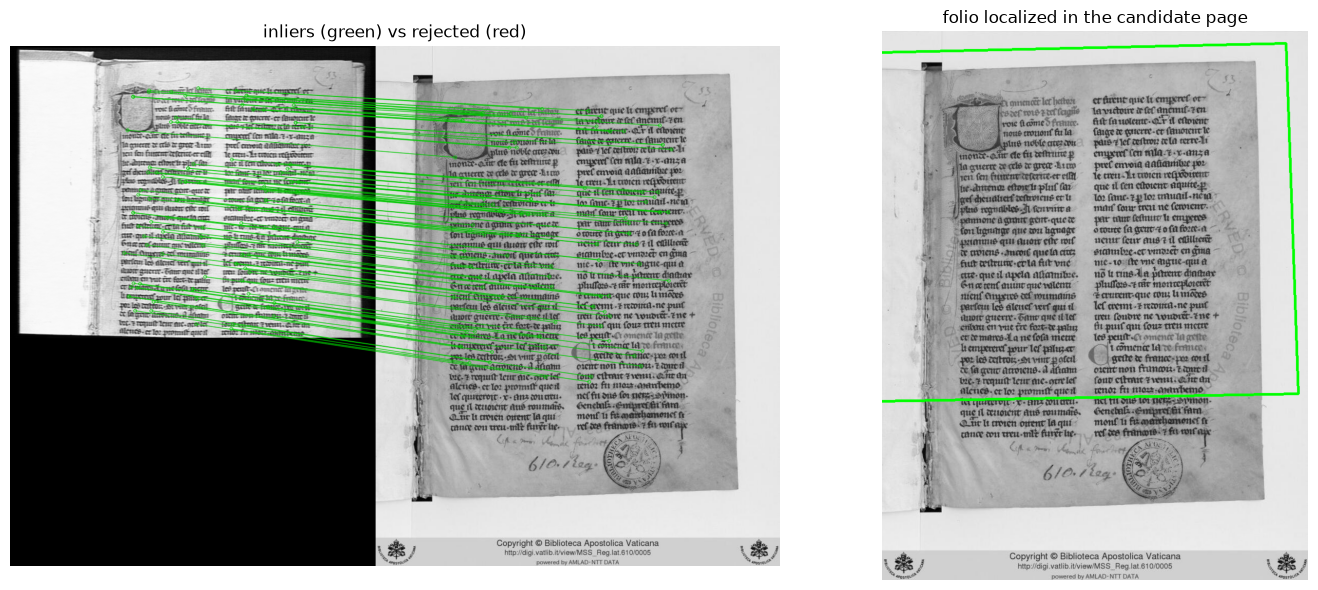

In [9]:
import matplotlib.pyplot as plt

from cropcatcher import Matcher
from cropcatcher.visualization import draw_localization, draw_matches

%matplotlib inline

best_rows = top_n(reconciled[reconciled["status"] == "ok"], 1)

if len(best_rows):
    target = best_rows.sort_values("score", ascending=False).iloc[0]
    query_path = usable.loc[
        usable["odil_folio_id"] == target["odil_folio_id"], "image_path"
    ].iloc[0]

    matcher = Matcher(method=METHOD)
    debug = matcher.explain_iiif(
        query=query_path,
        service_id=target["candidate_service_id"],
        size=SIZE,
    )

    print(f"folio {target['folio']} ({target['title'][:40]})")
    print(f"  -> canvas {target['candidate_canvas_label']}")
    print(f"  score={debug.result.score:.3f}  inliers={debug.result.inliers}"
          f"  inlier_ratio={debug.result.inlier_ratio:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].imshow(draw_matches(debug)[:, :, ::-1])
    axes[0].set_title("inliers (green) vs rejected (red)")
    axes[0].axis("off")
    axes[1].imshow(
        draw_localization(
            debug.candidate_image, debug.query_image.shape, debug.result.homography
        )[:, :, ::-1]
    )
    axes[1].set_title("folio localized in the candidate page")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("no match to visualize")


## Passage à l'échelle / Scaling up

**FR** — Ordres de grandeur une machine 16 cœurs, SIFT, canvas en `!1024,1024` : télécharger et décrire un canvas prend de l'ordre de 100 à 200 ms selon le serveur, une fois par manifeste ; comparer un folio à un canvas environ 150 ms. Pour un manuscrit de `F` folios et `N` canvas indexés, le coût est donc `N × 0,19 s` une fois, plus `F × N × 0,16 s`. Le second terme est quadratique et domine dès que `F > 1` : le Vatican `Reg.lat.1`, 1388 folios, coûterait à lui seul ~87 h à `N = 1400`.

**FR** — Le partage entre les deux termes dépend du nombre de folios par manuscrit : un canvas est indexé une fois, mais comparé à chacun des folios du manifeste. Avec 7,7 folios par manifeste en moyenne, les recherches dominent nettement, d'environ un ordre de grandeur. Les heures exactes varient d'une exécution à l'autre selon le débit réseau : fiez-vous à la projection calculée en section 5, pas à un chiffre figé. L'indexation restant bornée par le téléchargement, réduire le nombre de canvas traités est le seul levier qui attaque les deux termes à la fois.

**FR** — Traiter les 20 351 lignes exploitables est un job batch, pas une exécution interactive. Les leviers, du plus au moins efficace :

1. **Restreindre la fenêtre de recherche**, indexation comprise : le seul levier qui attaque les deux termes.
2. **`MAX_CANVASES`**, simple mais aveugle : un canvas au-delà de la borne ne peut pas être trouvé.
3. **`METHOD = "orb"`**, ~11× plus rapide sur les comparaisons, soit le terme dominant ici ; l'indexation restant bornée par le téléchargement, le gain global reste inférieur à ×11.
4. **Reprise sur interruption**, déjà assurée par `RESUME`.

**EN** — Orders of magnitude on machine with 16 cores, SIFT, canvases at `!1024,1024`: downloading and describing a canvas takes 100 to 200 ms depending on the server, once per manifest; comparing a folio to a canvas about 150 ms. For a manuscript with `F` folios and `N` indexed canvases the cost is `N × 0.19 s` once, plus `F × N × 0.16 s`. The second term is quadratic and dominates as soon as `F > 1`: Vatican `Reg.lat.1`, 1388 folios, would alone cost ~87 h at `N = 1400`.

**EN** — How the two terms split depends on how many folios share a manuscript: a canvas is indexed once but compared against each of the manifest's folios. At 7.7 folios per manifest on average, searching dominates clearly, by roughly an order of magnitude. The exact hours move between runs with network throughput, so trust the projection computed in section 5 rather than a fixed figure. Indexing stays gated by downloading, so cutting the number of canvases processed is the only lever that attacks both terms at once.

**EN** — Running all 20,351 usable rows is a batch job, not an interactive run. Levers, most to least effective:

1. **Restrict the search window**, indexing included: the only lever that hits both terms.
2. **`MAX_CANVASES`**, simple but blind: a canvas beyond the cap can never be found.
3. **`METHOD = "orb"`**, ~11× faster on comparisons, which is the dominant term here; indexing stays download-bound, so the overall gain stays below ×11.
4. **Resumability**, already handled by `RESUME`.